# Importing Libraries

In [85]:
import pandas as pd
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create a Sample Dataset

In [86]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    random_state=42
)

# Split into Training and Test and Validation Sets

In [87]:
# First: separate the test set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Then: split the remaining data into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# 1.pipeline

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression()) 
])

pipeline.fit(X_train, y_train)

accuracy = pipeline.score(X_test, y_test)

print(f"Accuracy: {accuracy:.3f}")

# Output:
# Your result may vary slightly depending on the dataset and random seed.

Accuracy: 0.627


# 2.make_pipeline

In [89]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

pipeline.fit(X_train, y_train)

print(pipeline.score(X_test, y_test))

# Output:
# Your result may vary slightly depending on the dataset and random seed.

0.6266666666666667


# 3.ColumnTransformer

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

data = pd.DataFrame({
    "age": [25,30,35,40],
    "income": [50000,60000,70000,80000],
    "department": ["HR","IT","Finance","IT"]
})

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["age","income"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["department"])
])

X_transformed = preprocessor.fit_transform(data)

print(X_transformed.shape)

(4, 5)


# 4.FunctionTransformer

In [33]:
from sklearn.preprocessing import FunctionTransformer

def log_transform(X):
    return np.log1p(X)

transformer = FunctionTransformer(log_transform)

X_log = transformer.fit_transform(X_train)

/var/folders/g3/hwwd8nzx1s1g8p458ygp9p500000gn/T/ipykernel_10625/3099146082.py:4: RuntimeWarning: invalid value encountered in log1p
  return np.log1p(X)


# 5.get_params

In [34]:
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

params = pipeline.get_params()

print(list(params.keys())[:5])

['memory', 'steps', 'transform_input', 'verbose', 'standardscaler']


# 6.set_params()

In [35]:
pipeline.set_params(
    logisticregression__C=10
)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,10


# 7.set_config(display="diagram")

In [36]:
from sklearn import set_config

set_config(display="diagram")

pipeline

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,10


# 8.SimpleImputer()

In [37]:
from sklearn.impute import SimpleImputer
import numpy as np

X = np.array([
    [25, 50000],
    [30, np.nan],
    [35, 70000]
])

imputer = SimpleImputer(strategy="mean")

X_clean = imputer.fit_transform(X)

print(X_clean)

[[2.5e+01 5.0e+04]
 [3.0e+01 6.0e+04]
 [3.5e+01 7.0e+04]]


# 9.StandardScaler

In [38]:
from sklearn.preprocessing import StandardScaler

X = [
    [100, 1000],
    [200, 2000],
    [300, 3000]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


# 10.MinMaxScaler

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform([
    [10],
    [20],
    [30]
])

print(X_scaled)

[[0. ]
 [0.5]
 [1. ]]


# 11.RobustScaler

In [40]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform([
    [10],
    [20],
    [30],
    [1000]
])

# 12.OneHotEncoder

In [41]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

data = [
    ["Python"],
    ["SQL"],
    ["Python"]
]

encoded = encoder.fit_transform(data)

print(encoded.toarray())

[[1. 0.]
 [0. 1.]
 [1. 0.]]


# 13.LabelEncoder

In [42]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = [
    "cat",
    "dog",
    "cat"
]

encoded = encoder.fit_transform(y)

print(encoded)

[0 1 0]


# 14.PolynomialFeatures

In [43]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X = [[2,3]]

X_poly = poly.fit_transform(X)

print(X_poly)

[[1. 2. 3. 4. 6. 9.]]


# 15.VarianceThreshold

In [44]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

X = pd.DataFrame({
    "age": [20, 21, 22, 23],
    "country": [1, 1, 1, 1],
    "salary": [30000, 35000, 40000, 45000]
})

selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

print(X_selected.shape)

(4, 2)


# 16.SelectKBest

In [45]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=5
)

X_new = selector.fit_transform(X_train, y_train)

# 17.SelectFromModel

In [46]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

selector = SelectFromModel(
    RandomForestClassifier(random_state=42)
)

X_selected = selector.fit_transform(X_train, y_train)

# 18.RFE

In [47]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

selector = RFE(
    estimator=model,
    n_features_to_select=5
)

X_selected = selector.fit_transform(X_train, y_train)

# 19.PCA

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X_train)

print(X_reduced.shape)

(800, 2)


# 20.RFECV

In [49]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

selector = RFECV(
    estimator=model,
    step=1,
    cv=5,
    scoring="accuracy"
)

X_selected = selector.fit_transform(X_train, y_train)

print("Optimal number of features:", selector.n_features_)

Optimal number of features: 5


# 21.SequentialFeatureSelector

In [50]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5
)

X_selected = selector.fit_transform(X_train, y_train)

# 22. accuracy_score

In [51]:
from sklearn.metrics import accuracy_score

y_true = [1, 0, 1, 1, 0]
y_pred = [1, 0, 1, 0, 0]

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(accuracy)

0.8


# 23. precision_score

In [52]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred
)

print(precision)

1.0


# 24. recall_score

In [53]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_true,
    y_pred
)

print(recall)

0.6666666666666666


# 25. f1_score()

In [54]:
from sklearn.metrics import f1_score

score = f1_score(
    y_true,
    y_pred
)

print(score)

0.8


# 26. confusion_matrix

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[2 0]
 [1 2]]


# 27. classification_report

In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



# 28. mean_squared_error

In [57]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_true,
    y_pred
)

print(mse)

0.2


# 29. mean_absolute_error

In [58]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_true,
    y_pred
)

print(mae)

0.2


# 30. r2_score

In [59]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_true,
    y_pred
)

print(r2)

0.16666666666666674


# New Dataset 

In [60]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create a classification dataset
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_classes=2,
    random_state=42,
    weights=[0.7, 0.3]  # Slightly imbalanced
)

# Convert to DataFrame for better visualization
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples per class: {np.bincount(y)}")
print(f"Class distribution: {np.bincount(y)[0]/len(y):.2%} vs {np.bincount(y)[1]/len(y):.2%}")

# Split for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Dataset Info:
Shape: (500, 11)
Features: 10
Samples per class: [348 152]
Class distribution: 69.60% vs 30.40%

Training set: 400 samples
Test set: 100 samples


# 31. cross_val_score

In [61]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000, random_state=42)

# Perform 5-fold cross-validation
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy'       # Evaluation metric
)

print("Cross-validation scores:", scores)
print(f"Mean accuracy: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

Cross-validation scores: [0.8375 0.8125 0.8375 0.75   0.7375]
Mean accuracy: 0.795 (+/- 0.086)


# 32. KFold()

In [62]:
from sklearn.model_selection import KFold

# Create KFold object
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Manual cross-validation loop
model = LogisticRegression(max_iter=1000, random_state=42)

fold_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    # Split data
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # Train and evaluate
    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_val_fold)
    score = accuracy_score(y_val_fold, y_pred)
    
    print(f"Fold {fold + 1}: Train samples = {len(train_idx)}, "
          f"Val samples = {len(val_idx)}, Accuracy = {score:.3f}")
    fold_scores.append(score)

print(f"\nMean accuracy: {np.mean(fold_scores):.3f} (+/- {np.std(fold_scores) * 2:.3f})")

Fold 1: Train samples = 320, Val samples = 80, Accuracy = 0.838
Fold 2: Train samples = 320, Val samples = 80, Accuracy = 0.838
Fold 3: Train samples = 320, Val samples = 80, Accuracy = 0.812
Fold 4: Train samples = 320, Val samples = 80, Accuracy = 0.700
Fold 5: Train samples = 320, Val samples = 80, Accuracy = 0.787

Mean accuracy: 0.795 (+/- 0.102)


# 33. StratifiedKFold

In [63]:
from sklearn.model_selection import StratifiedKFold

# Check class distribution in training set
print(f"Training set class distribution: {np.bincount(y_train)}")
print(f"Class 0: {np.bincount(y_train)[0]/len(y_train):.2%}")
print(f"Class 1: {np.bincount(y_train)[1]/len(y_train):.2%}")

# Create StratifiedKFold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Show class distribution per fold
model = LogisticRegression(max_iter=1000, random_state=42)
fold_scores = []

print("\nClass distribution in each fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):  # Note: y_train passed here
    # Check validation set class distribution
    y_val = y_train[val_idx]
    class0 = np.sum(y_val == 0)
    class1 = np.sum(y_val == 1)
    
    print(f"Fold {fold + 1}: Class 0 = {class0} ({class0/len(y_val):.2%}), "
          f"Class 1 = {class1} ({class1/len(y_val):.2%})")
    
    # Train and evaluate
    model.fit(X_train[train_idx], y_train[train_idx])
    y_pred = model.predict(X_train[val_idx])
    score = accuracy_score(y_val, y_pred)
    fold_scores.append(score)

print(f"\nMean accuracy: {np.mean(fold_scores):.3f}")

Training set class distribution: [281 119]
Class 0: 70.25%
Class 1: 29.75%

Class distribution in each fold:
Fold 1: Class 0 = 56 (70.00%), Class 1 = 24 (30.00%)
Fold 2: Class 0 = 56 (70.00%), Class 1 = 24 (30.00%)
Fold 3: Class 0 = 56 (70.00%), Class 1 = 24 (30.00%)
Fold 4: Class 0 = 56 (70.00%), Class 1 = 24 (30.00%)
Fold 5: Class 0 = 57 (71.25%), Class 1 = 23 (28.75%)

Mean accuracy: 0.787


# 34. LeaveOneOut

In [64]:
from sklearn.model_selection import LeaveOneOut

# Create small dataset for demonstration
X_small, y_small = make_classification(
    n_samples=10,
    n_features=5,
    random_state=42
)

# Create LeaveOneOut
loo = LeaveOneOut()

model = LogisticRegression(max_iter=1000, random_state=42)

# Manual evaluation
correct_predictions = 0
total_predictions = 0

for train_idx, val_idx in loo.split(X_small):
    # Train on all but one sample
    model.fit(X_small[train_idx], y_small[train_idx])
    
    # Predict on the left-out sample
    y_pred = model.predict(X_small[val_idx])
    
    # Check if correct
    if y_pred == y_small[val_idx]:
        correct_predictions += 1
    total_predictions += 1
    
    # Show status every few iterations
    if total_predictions % 5 == 0 or total_predictions == 1:
        print(f"Processed {total_predictions} samples, "
              f"Accuracy so far: {correct_predictions/total_predictions:.3f}")

# Final accuracy
loo_accuracy = correct_predictions / total_predictions
print(f"\nFinal LeaveOneOut accuracy: {loo_accuracy:.3f}")

# Or use cross_val_score for convenience
from sklearn.model_selection import cross_val_score
loo = LeaveOneOut()
scores = cross_val_score(model, X_small, y_small, cv=loo)
print(f"LeaveOneOut CV scores: {scores}")
print(f"Mean accuracy: {scores.mean():.3f}")

Processed 1 samples, Accuracy so far: 0.000
Processed 5 samples, Accuracy so far: 0.800
Processed 10 samples, Accuracy so far: 0.800

Final LeaveOneOut accuracy: 0.800
LeaveOneOut CV scores: [0. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
Mean accuracy: 0.800


# 35. cross_validate

In [65]:
from sklearn.model_selection import cross_validate

# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Multiple scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform cross-validation with multiple metrics
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=True,   # Also return training scores
    return_estimator=False,    # Set True to access models
    n_jobs=-1,
    verbose=1
)

# Results
print("Cross-Validation Results:")
print("-" * 50)
print(f"Train accuracy: {cv_results['train_accuracy'].mean():.3f} (+/- {cv_results['train_accuracy'].std() * 2:.3f})")
print(f"Test accuracy:  {cv_results['test_accuracy'].mean():.3f} (+/- {cv_results['test_accuracy'].std() * 2:.3f})")
print(f"Train F1:       {cv_results['train_f1'].mean():.3f} (+/- {cv_results['train_f1'].std() * 2:.3f})")
print(f"Test F1:        {cv_results['test_f1'].mean():.3f} (+/- {cv_results['test_f1'].std() * 2:.3f})")
print(f"Fit time:       {cv_results['fit_time'].mean():.3f} seconds")
print(f"Score time:     {cv_results['score_time'].mean():.3f} seconds")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Cross-Validation Results:
--------------------------------------------------
Train accuracy: 1.000 (+/- 0.000)
Test accuracy:  0.850 (+/- 0.045)
Train F1:       1.000 (+/- 0.000)
Test F1:        0.702 (+/- 0.120)
Fit time:       0.277 seconds
Score time:     0.022 seconds


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.2s remaining:    7.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.2s finished


# 36. train_test_split() Advanced Usage

In [66]:
from sklearn.model_selection import train_test_split

print("1. Basic Split (Default):")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Class distribution (Train): {np.bincount(y_train)}")
print(f"Class distribution (Test): {np.bincount(y_test)}")

print("\n2. Stratified Split (Maintains Class Distribution):")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintains class proportions
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Class distribution (Train): {np.bincount(y_train)}")
print(f"Class distribution (Test): {np.bincount(y_test)}")

print("\n3. Shuffled vs Unshuffled:")
print("With shuffle=True (default):")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"First 5 target values (shuffled): {y_train[:5]}")

print("With shuffle=False:")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)
print(f"First 5 target values (unshuffled): {y_train[:5]}")

print("\n4. Reproducibility:")
print("Same random_state = Same split")
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"First 5 targets (split 1): {y_train1[:5]}")
print(f"First 5 targets (split 2): {y_train2[:5]}")
print(f"Are they identical? {np.array_equal(y_train1, y_train2)}")


1. Basic Split (Default):
Train: 400, Test: 100
Class distribution (Train): [281 119]
Class distribution (Test): [67 33]

2. Stratified Split (Maintains Class Distribution):
Train: 400, Test: 100
Class distribution (Train): [278 122]
Class distribution (Test): [70 30]

3. Shuffled vs Unshuffled:
With shuffle=True (default):
First 5 target values (shuffled): [1 1 0 0 0]
With shuffle=False:
First 5 target values (unshuffled): [0 1 0 0 1]

4. Reproducibility:
Same random_state = Same split
First 5 targets (split 1): [1 1 0 0 0]
First 5 targets (split 2): [1 1 0 0 0]
Are they identical? True


# 37. GridSearchCV

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

model = SVC()
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)  

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

test_score = grid.score(X_test, y_test)
print("Test score:", test_score)

Best parameters: {'C': 10, 'kernel': 'rbf'}
Best CV score: 0.9185714285714285
Test score: 0.9066666666666666


# 38. RandomizedSearchCV

In [92]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)

search.fit(X_train, y_train)  

print("Best parameters:", search.best_params_)

test_score = search.score(X_test, y_test)
print("Test score:", test_score)

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Test score: 0.8066666666666666


# 39. Pipeline + GridSearchCV

In [69]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "C": [1, 10],
    "kernel": ["linear", "rbf"]
}

for params in ParameterGrid(param_grid):
    print(params)

{'C': 1, 'kernel': 'linear'}
{'C': 1, 'kernel': 'rbf'}
{'C': 10, 'kernel': 'linear'}
{'C': 10, 'kernel': 'rbf'}


# 40. validation_curve

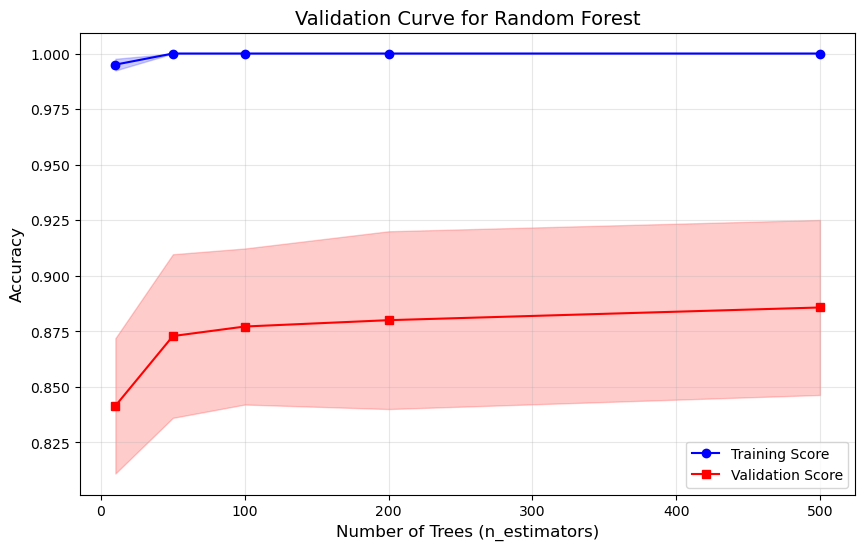

Optimal trees: 500, Best accuracy: 0.886


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
param_range = [10, 50, 100, 200, 500]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), 
    X_train, y_train,  # ✅ Use training data only
    param_name="n_estimators", 
    param_range=param_range,
    cv=5, 
    scoring="accuracy"
)

train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
val_mean, val_std = np.mean(val_scores, axis=1), np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, 'bo-', label="Training Score")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(param_range, val_mean, 'rs-', label="Validation Score")
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.2, color='red')
plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Validation Curve for Random Forest", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

optimal_idx = np.argmax(val_mean)
print(f"Optimal trees: {param_range[optimal_idx]}, Best accuracy: {val_mean[optimal_idx]:.3f}")

# 41. learning_curve

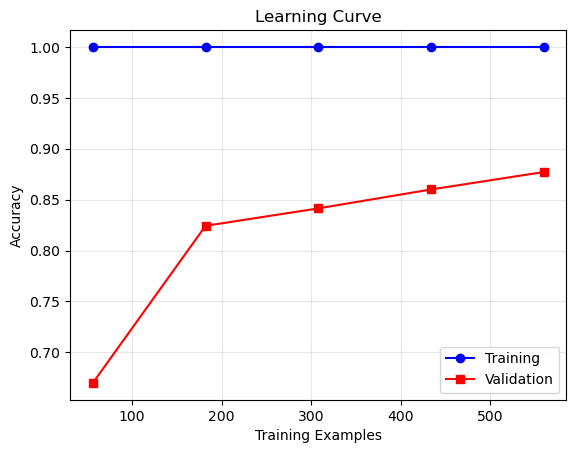

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

sizes, train, val = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train,  
    train_sizes=np.linspace(.1, 1, 5), 
    cv=5, 
    scoring="accuracy"
)

plt.plot(sizes, train.mean(1), "bo-", label="Training")
plt.plot(sizes, val.mean(1), "rs-", label="Validation")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(alpha=.3)
plt.show()

# 42. VotingClassifier

In [72]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

model = VotingClassifier([
    ("lr", LogisticRegression()),
    ("rf", RandomForestClassifier(random_state=42)),
    ("svc", SVC())
])

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 43. VotingRegressor

In [73]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

model = VotingRegressor([
    ("lr", LinearRegression()),
    ("rf", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 44. RandomForestClassifier

In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 45. GradientBoostingClassifier

In [75]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 46. AdaBoostClassifier

In [76]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 47. StackingClassifier

In [77]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

model = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(random_state=42)),
        ("svc", SVC())
    ],
    final_estimator=LogisticRegression()
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 48. CalibrationDisplay

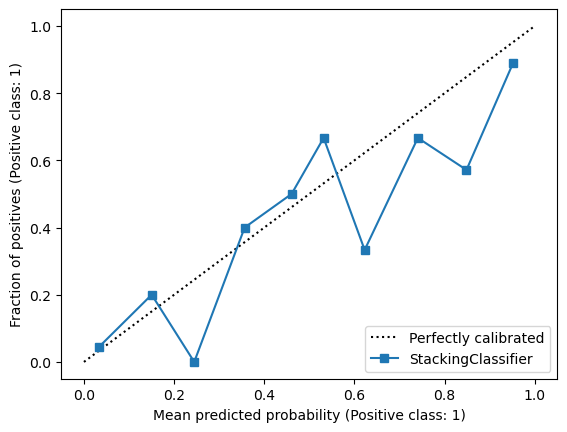

In [78]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    model, X_test, y_test, n_bins=10
)
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")


# 49. permutation_importance

In [82]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

for i, importance in enumerate(result.importances_mean):
    print(f"Feature {i}: {importance:.3f}")

Feature 0: 0.052
Feature 1: 0.014
Feature 2: 0.046
Feature 3: 0.017
Feature 4: 0.039
Feature 5: 0.035
Feature 6: 0.034
Feature 7: 0.011
Feature 8: 0.015
Feature 9: 0.111


Exception ignored in: <function ResourceTracker.__del__ at 0x1030d9b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104c49b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1092b1b20>
Traceback (most recent call last

# 50. Pipeline + Model Persistence with joblib

In [84]:
import joblib

pipeline.fit(X_train, y_train)
joblib.dump(pipeline, "model.pkl")
loaded_pipeline = joblib.load("model.pkl")

predictions = loaded_pipeline.predict(X_test)